# Proyecto B: Sistema de Predicción de Abandono de Clientes (Churn)
### Curso: BD-151 Inteligencia Artificial Aplicada
### Colegio Universitario de Cartago

**Dataset:** Telco Customer Churn
**Modelos:** Clasificación Binaria (Churn Yes/No) + Regresión (Probabilidad de riesgo 0.0 - 1.0)

---
## Descripción del Problema
Desarrollar un sistema que prediga qué clientes tienen mayor probabilidad de abandonar un servicio de telecomunicaciones. El sistema identifica clientes en riesgo y los clasifica por nivel de urgencia para implementar estrategias de retención.

## Flujo del Notebook
1. Importación de librerías
2. Carga del dataset
3. Análisis Exploratorio de Datos (EDA)
4. Train Test Split
5. Escalado de datos
6. Manejo de datos desbalanceados
7. Modelo 1 - Clasificación Binaria
8. Modelo 2 - Regresión (probabilidad de churn)
9. Comparación de modelos y conclusiones

# 1. Importar librerías

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
# 2. Importación del Dataset

**Fuente:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Variables principales:**
- `customerID`: Identificador único del cliente
- `gender`: Género del cliente
- `SeniorCitizen`: Si es ciudadano mayor (0/1)
- `tenure`: Meses como cliente
- `Contract`: Tipo de contrato (Month-to-month, One year, Two year)
- `MonthlyCharges`: Cargo mensual
- `TotalCharges`: Cargo total acumulado
- `Churn`: Variable objetivo (Yes/No)

In [10]:
customer = pd.read_csv("C:\BD_ANN\WA_Fn-UseC_-Telco-Customer-Churn.csv", sep=',')
customer.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

---
# 3. Análisis Exploratorio de Datos (EDA) + Preprocesado

## 3.1 Limpieza Inicial

In [12]:
customer.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
(customer == '').sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
customer.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [15]:
(customer['TotalCharges'] == '').sum()

np.int64(0)

In [16]:
customer['TotalCharges'].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [17]:
pd.to_numeric(customer['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [18]:
customer['TotalCharges'] = pd.to_numeric(customer['TotalCharges'], errors='coerce')

In [19]:
customer = customer.dropna(subset=['TotalCharges'])

In [20]:
print(customer['TotalCharges'].dtype)
print(customer['TotalCharges'].isnull().sum())

float64
0


In [22]:
customer.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


## 3.2 Gráficos

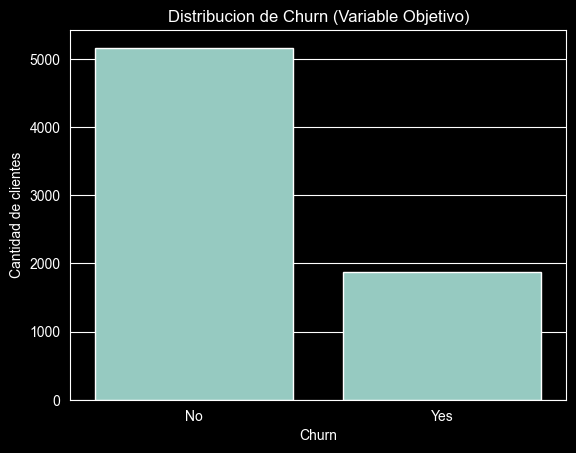

In [23]:
# NOTA: El dataset esta desbalanceado (~73% No Churn vs ~27% Churn), lo trataremos con class_weight
sns.countplot(x='Churn', data=customer)
plt.title('Distribucion de Churn (Variable Objetivo)')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

In [25]:
# Porcentaje de churn
print(customer['Churn'].value_counts())
print()
print(customer['Churn'].value_counts(normalize=True)*100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


### 3.2.2 Tasa de Churn por Segmento

Analizamos cómo varía el churn según diferentes segmentos del cliente.
Esto nos ayuda a identificar qué variables tienen mayor impacto en la decisión de abandono.

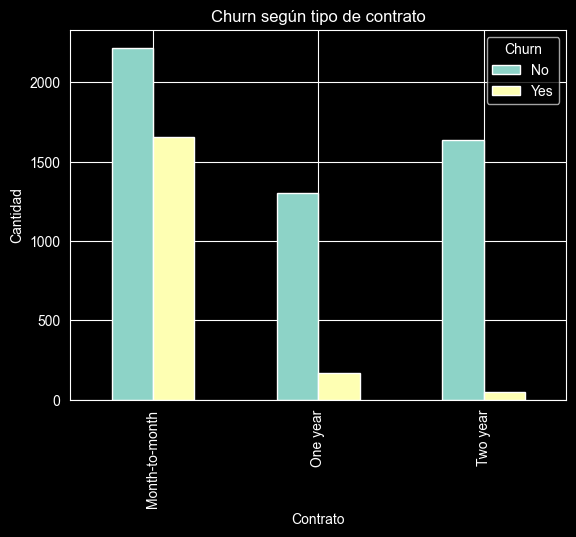

In [26]:
pd.crosstab(customer['Contract'], customer['Churn']).plot(kind='bar')
plt.title('Churn según tipo de contrato')
plt.xlabel('Contrato')
plt.ylabel('Cantidad')
plt.show()

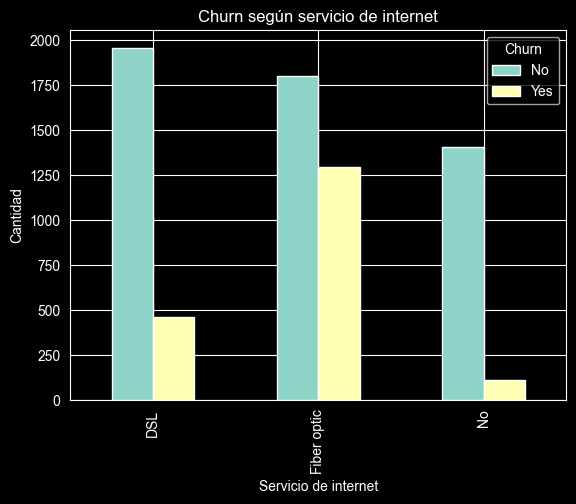

In [27]:
pd.crosstab(customer['InternetService'], customer['Churn']).plot(kind='bar')
plt.title('Churn según servicio de internet')
plt.xlabel('Servicio de internet')
plt.ylabel('Cantidad')
plt.show()

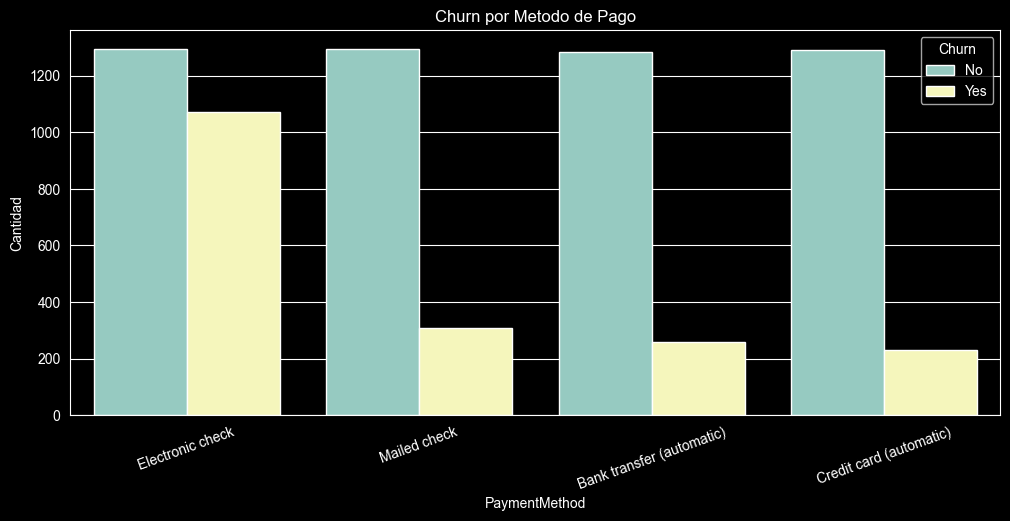

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=customer)
plt.title('Churn por Metodo de Pago')
plt.xticks(rotation=20)
plt.ylabel('Cantidad')
plt.show()

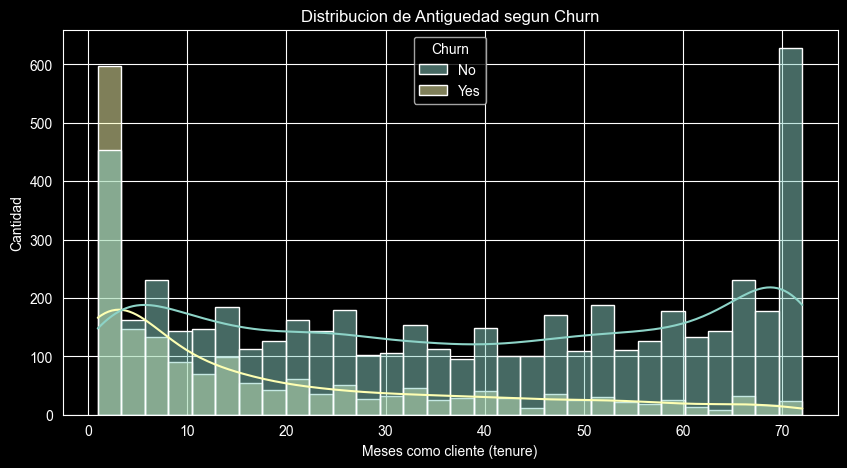

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(data=customer, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Distribucion de Antiguedad segun Churn')
plt.xlabel('Meses como cliente (tenure)')
plt.ylabel('Cantidad')
plt.show()

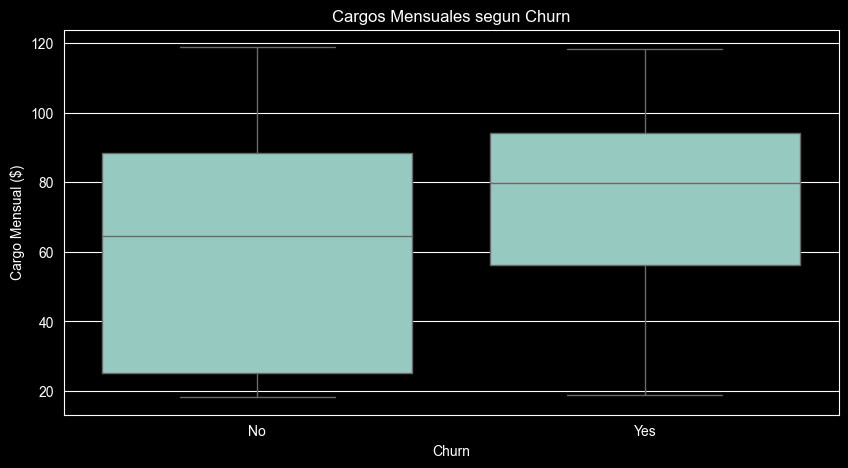

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=customer)
plt.title('Cargos Mensuales segun Churn')
plt.xlabel('Churn')
plt.ylabel('Cargo Mensual ($)')
plt.show()

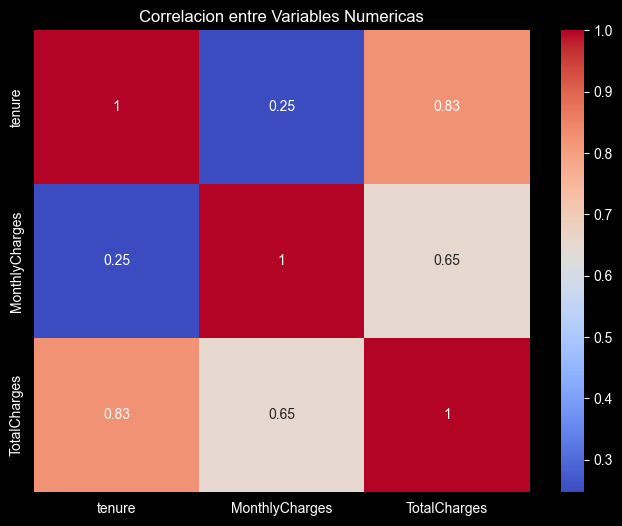

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(customer[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlacion entre Variables Numericas')
plt.show()